# HAFTA 7: GPT ve Self-Attention Mekanizmasını Sıfırdan İnşa Etmek

Bu hafta, modern Büyük Dil Modellerinin (LLM) kalbini oluşturan **Transformer** mimarisinin en kritik yapı taşına giriş yapıyoruz: **Self-Attention**.

Bu notebook'ta adım adım:
1. Tiny Shakespeare veri setini okuyup karakter düzeyinde bir tokenizer yazacağız.
2. Karşılaştırma tabanımız (baseline) olacak standart bir Bigram Dil Modeli kurup eğiteceğiz.
3. Geçmiş bağlamın ağırlıklı ortalamasını 3 farklı yoldan (döngü, alt üçgen matris çarpımı ve maskelenmiş softmax) alarak matris çarpımının ardındaki hileyi keşfedeceğiz.
4. Query, Key, Value kavramlarıyla dinamik ve öğrenilebilir bir **Tek Başlıklı Self-Attention (Single Head)** hücresi kuracağız.
5. Head'i modelimize entegre edip geçmiş bağlama bakabilmenin kaybı (val loss) nasıl düşürdüğünü gözlemleyeceğiz.

# Görev 1
Veriyi hazırla ve tabanı kur. Tiny Shakespeare'i oku, karakter tokenizer'ını yaz (encode, decode), veriyi %90 train, %10 val diye ayır. Rastgele parçalardan batch çeken get_batch fonksiyonunu yaz. Hafta 2'deki bigram modelini nn.Module olarak kur, eğit, val loss'u kaydet. Bu senin karşılaştırma tabanın. (7:52 - 38:00)


### Veri Seti ve Karakter Düzeyinde Tokenizer

Shakespeare metnini indirip karakter kümesini çıkarıyoruz. Karakterleri tam sayılara (`encode`), tam sayıları tekrar karaktere (`decode`) dönüştüren sözlükleri oluşturuyoruz.



In [13]:
import torch
import torch.nn as nn
from torch.nn import functional as F

torch.manual_seed(1337)

# Dosya yerelde yoksa wget veya requests ile indirilebilir:
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Toplam karakter sayısı: {len(text)}")

# Karakter kümesi ve sözlükler
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Sözlük boyutu (benzersiz karakterler): {vocab_size}")
print(f"Karakterler: {''.join(chars)}")

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s] # Metni tam sayı listesine çevirir
decode = lambda l: ''.join([itos[i] for i in l]) # Sayı listesini metne geri çevirir

# Örnek test
print(f"'hello' encode: {encode('hello')}")
print(f"Geri decode: {decode(encode('hello'))}")

Toplam karakter sayısı: 1115394
Sözlük boyutu (benzersiz karakterler): 65
Karakterler: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
'hello' encode: [46, 43, 50, 50, 53]
Geri decode: hello


### Veriyi Tensöre Çevirme ve Train/Val Ayrımı
Tüm metni PyTorch tensörüne çevirip ilk %90'ını eğitim, kalan %10'unu doğrulama kümesi olarak ayırıyoruz.

In [14]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"Train veri uzunluğu: {len(train_data)}")
print(f"Val veri uzunluğu  : {len(val_data)}")

Train veri uzunluğu: 1003854
Val veri uzunluğu  : 111540


### Rastgele Parçalardan Batch Çekme (`get_batch`)
Metin çok uzun olduğu için modele rastgele pencereler kesip mini-batch olarak veriyoruz.
- `block_size`: Modelin bir tahminde bulunurken geriye doğru bakabileceği maksimum karakter bağlam uzunluğu.
- `batch_size`: Paralel işlenecek bağımsız dizi sayısı.

In [15]:
batch_size = 4  # Paralel işlenecek dizi sayısı
block_size = 8  # Maksimum bağlam uzunluğu

def get_batch(split):
    # İlgili veri kümesini seç
    dataset = train_data if split == 'train' else val_data
    # Rastgele başlangıç indeksleri seç (son sınır block_size kadar geride olmalı)
    ix = torch.randint(len(dataset) - block_size, (batch_size,))
    # Girdi (x) ve bir karakter ötelenmiş hedef (y) tensörlerini yığ
    x = torch.stack([dataset[i:i+block_size] for i in ix])
    y = torch.stack([dataset[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print(f"Girdi xb şekli: {xb.shape}")
print(f"Hedef yb şekli: {yb.shape}")

# Bir örneğin bağlam-hedef ilişkisini görelim:
for t in range(block_size):
    context = xb[0, :t+1]
    target = yb[0, t]
    print(f"Bağlam: {context.tolist()} (yani '{decode(context.tolist())}') ---> Hedef: {target.item()} ('{itos[target.item()]}')")

Girdi xb şekli: torch.Size([4, 8])
Hedef yb şekli: torch.Size([4, 8])
Bağlam: [24] (yani 'L') ---> Hedef: 43 ('e')
Bağlam: [24, 43] (yani 'Le') ---> Hedef: 58 ('t')
Bağlam: [24, 43, 58] (yani 'Let') ---> Hedef: 5 (''')
Bağlam: [24, 43, 58, 5] (yani 'Let'') ---> Hedef: 57 ('s')
Bağlam: [24, 43, 58, 5, 57] (yani 'Let's') ---> Hedef: 1 (' ')
Bağlam: [24, 43, 58, 5, 57, 1] (yani 'Let's ') ---> Hedef: 46 ('h')
Bağlam: [24, 43, 58, 5, 57, 1, 46] (yani 'Let's h') ---> Hedef: 43 ('e')
Bağlam: [24, 43, 58, 5, 57, 1, 46, 43] (yani 'Let's he') ---> Hedef: 39 ('a')


### Taban Bigram Dil Modeli (nn.Module)
Bu model sadece o anki karaktere bakar, geçmiş bağlamı hiç dikkate almaz. Gelecek adımlardaki düşüşü ölçmek için kıyaslama tabanımızdır.

In [16]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # Her token doğrudan bir sonraki tokenın logit puanını bir embedding tablosundan çeker
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        # idx: (B, T) boyutunda token indeksleri
        logits = self.token_embedding_table(idx) # (B, T, C)

        if targets is None:
            loss = None
        else:
            # F.cross_entropy girdiyi (N, C) biçiminde bekler; boyutları düzleştiriyoruz:
            B, T, C = logits.shape
            logits_flat = logits.view(B*T, C)
            targets_flat = targets.view(B*T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx: mevcut bağlam (B, T)
        for _ in range(max_new_tokens):
            # Tahminleri al
            logits, _ = self(idx)
            # Yalnızca son zaman adımının logitlerine odaklan
            logits = logits[:, -1, :] # (B, C)
            # Olasılıklara çevir
            probs = F.softmax(logits, dim=-1) # (B, C)
            # Dağılımdan bir sonraki token'ı çek
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # Dizinin sonuna ekle
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

# Modeli oluşturalım
m_baseline = BigramLanguageModel(vocab_size)
logits, loss = m_baseline(xb, yb)
print(f"Eğitimsiz başlangıç kaybı: {loss.item():.4f} (Beklenen: ~{-torch.log(torch.tensor(1/vocab_size)).item():.4f})")

# Eğitimsiz metin üretimi (tamamen rastgele harf yığını üretir)
context = torch.zeros((1, 1), dtype=torch.long)
print(decode(m_baseline.generate(context, max_new_tokens=100)[0].tolist()))

Eğitimsiz başlangıç kaybı: 5.0364 (Beklenen: ~4.1744)

lfJeukRuaRJKXAYtXzfJ:HEPiu--sDioi;ILCo3pHNTmDwJsfheKRxZCFs
lZJ XQc?:s:HEzEnXalEPklcPU cL'DpdLCafBheH


### Kayıp Tahmin Fonksiyonu ve Bigram Modelinin Eğitimi
Eğitim gürültüsünü azaltmak için mini-batch ortalaması alan bir fonksiyon kurup modeli optimize ediyoruz.

In [17]:
eval_iters = 200

@torch.no_grad()
def estimate_loss(model):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(m_baseline.parameters(), lr=1e-2)

batch_size = 32
for iter in range(3000):
    if iter % 500 == 0:
        losses = estimate_loss(m_baseline)
        print(f"Adım {iter}: Train Loss = {losses['train']:.4f}, Val Loss = {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = m_baseline(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

baseline_losses = estimate_loss(m_baseline)
print("\n--- TABAN BİGRAM MODELİ SONUCU: ---")
print(f"Bigram Train Loss: {baseline_losses['train']:.4f}")
print(f"Bigram Val Loss  : {baseline_losses['val']:.4f}")

Adım 0: Train Loss = 4.6433, Val Loss = 4.6455
Adım 500: Train Loss = 2.5800, Val Loss = 2.6136
Adım 1000: Train Loss = 2.4892, Val Loss = 2.5084
Adım 1500: Train Loss = 2.4786, Val Loss = 2.5020
Adım 2000: Train Loss = 2.4547, Val Loss = 2.4999
Adım 2500: Train Loss = 2.4660, Val Loss = 2.4834

--- TABAN BİGRAM MODELİ SONUCU: ---
Bigram Train Loss: 2.4522
Bigram Val Loss  : 2.4940


# Görev 2 
Geçmişin ortalamasını üç yoldan al: for döngüsüyle, lower triangular matrisle (torch.tril) çarparak, softmax'la. Üçünün aynı sonucu verdiğini torch.allclose ile göster. Matris çarpımının neden ağırlıklı ortalama olduğunu kendi cümlelerinle yaz. (42:13 - 58:26)

### Geçmiş Bilgiyi Birleştirme Hilesi: Matris Çarpımıyla Ağırlıklı Ortalama

Karakter dizisinde her token'ın kendisinden önceki tüm karakterlerin ortalamasını almasını istiyoruz.
Bunu 3 farklı yoldan hesaplayıp sonuçların özdeşliğini `torch.allclose` ile doğrulayacağız:
1. Klasik iç içe `for` döngüleri.
2. Satır toplamları 1 yapılmış alt üçgen matris (`tril`) ile matris çarpımı.
3. Maskelenmiş (geleceği `-inf` yapılmış) Softmax.

In [18]:
B, T, C = 4, 8, 2 # 4 örnek, 8 zaman adımı, 2 öznitelik boyutu
x = torch.randn(B, T, C)

# YÖNTEM 1: İç içe for döngüsü (En yavaş yol)
# ===============================================
xbow1 = torch.zeros((B, T, C)) # xbow: "bag of words" (geçmişin ortalaması)
for b in range(B):
    for t in range(T):
        # 0'dan t'ye kadar olan tüm geçmiş adımları alıp ortalamasını hesapla
        xprev = x[b, :t+1] # (t+1, C)
        xbow1[b, t] = torch.mean(xprev, dim=0)

# YÖNTEM 2: Alt Üçgen Matris ile Çarpım (torch.tril)
# =================================================
# 1'lerden oluşan alt üçgen matris (geçmişe bakar, geleceği 0 yapar)
wei2 = torch.tril(torch.ones(T, T))
# Her satırın toplamı 1 olsun ki çarpım doğrudan ortalama versin
wei2 = wei2 / wei2.sum(1, keepdim=True)
# (T, T) @ (B, T, C) -> PyTorch broadcasting ile (B, T, T) @ (B, T, C) = (B, T, C)
xbow2 = wei2 @ x

# YÖNTEM 3: Maskelenmiş Softmax (Attention'da kullanılan modern biçim)
# ====================================================================
tril = torch.tril(torch.ones(T, T))
wei3 = torch.zeros((T, T))
# Gelecekteki adımları (tril == 0 olan yerleri) -sonsuz yap
wei3 = wei3.masked_fill(tril == 0, float('-inf'))
# Softmax al: exp(-inf) = 0 olacağından geleceğe 0, geçmişe eşit olasılık dağılır
wei3 = F.softmax(wei3, dim=-1)
xbow3 = wei3 @ x

# Üç yöntemin denkliğini kontrol ediyoruz:
check1_2 = torch.allclose(xbow1, xbow2)
check2_3 = torch.allclose(xbow2, xbow3)

print("--- GÖREV 2: ÜÇ YÖNTEMİN KARŞILAŞTIRILMASI ---")
print(f"Yöntem 1 ve Yöntem 2 eşleşti mi?: {check1_2}")
print(f"Yöntem 2 ve Yöntem 3 eşleşti mi?: {check2_3}")
print("\nSoftmax sonrası ağırlık matrisi wei (İlk birkaç satır):")
print(wei3[:4, :4])

--- GÖREV 2: ÜÇ YÖNTEMİN KARŞILAŞTIRILMASI ---
Yöntem 1 ve Yöntem 2 eşleşti mi?: True
Yöntem 2 ve Yöntem 3 eşleşti mi?: True

Softmax sonrası ağırlık matrisi wei (İlk birkaç satır):
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500]])


### Matris Çarpımının Neden Ağırlıklı Ortalama Olduğunun Açıklaması

Bir $(T, T)$ ağırlık matrisi ile $(T, C)$ veri tensörünü çarptığımızda:
- Çıktı matrisinin $t$. satırı, ağırlık matrisinin $t$. satır vektörü ile veri matrisinin sütunlarının iç çarpımıdır.
- Ağırlık matrisinin $t$. satırındaki her bir eleman $w_{t, i}$, verinin $i$. zaman adımına ne kadar katsayı verileceğini belirler.
- Eğer satırdaki değerlerin toplamı $1$ ise ($\sum_i w_{t, i} = 1$), bu işlem matematiksel olarak geçmişteki özellik vektörlerinin **ağırlıklı lineer kombinasyonudur (ağırlıklı ortalama)**.
- Alt üçgen maskesi (`tril`) sayesinde $i > t$ için katsayılar sıfırlanır; böylece zaman adımı $t$, henüz gerçekleşmemiş gelecek adımlardan veri sızdırmaz (autoregressive özellik).

# Görev 3:
Tek bir self-attention head yaz: query, key, value ve pozisyon embedding'i. Bir örnekte ağırlık matrisini (wei) yazdır, bir satırını oku: o token hangi token'lara ne kadar bakıyor. Skorları head_size'ın kareköküne neden böldüğümüzü sayıyla göster: bölmeden ve bölerek softmax çıktısını yan yana koy. (58:26 - 1:19:11)

### Dinamik İlgi: Query, Key, Value ve Pozisyon Embedding'i

Görev 2'de geçmiş token'ların ortalamasını alırken her token'a **eşit** ağırlık veriyorduk.
Self-Attention ile bu ağırlıklar sabit olmak yerine **veriye bağlı ve öğrenilebilir** hale gelir:
- **Query (Sorgu):** Token'ın *"Ben ne arıyorum?"* vektörü.
- **Key (Anahtar):** Token'ın *"Bende ne bilgi var?"* vektörü.
- **Value (Değer):** Token'lar anlaştığında taşınacak asıl içerik vektörü.
- **Scaled Dot-Product:** Query ile Key iç çarpımı yapılarak $\sqrt{d_k}$'ya bölünür.

In [19]:
# Query, Key, Value ve wei Ağırlık Matrisi
# =========================================
B, T, C = 4, 8, 32 # Batch=4, Süre=8, Özellik Boyutu=32
head_size = 16    # Attention başlığının boyut derinliği

x = torch.randn(B, T, C)

# Öğrenilebilir lineer katmanları
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

k = key(x)   # (B, T, head_size)
q = query(x) # (B, T, head_size)

# Skor hesabı: Her sorgu ile her anahtarın benzerliğini çarpıyoruz
# (B, T, head_size) @ (B, head_size, T) -> (B, T, T)
wei = q @ k.transpose(-2, -1) * (head_size ** -0.5)

# Nedensellik Maskesi: Geleceğe bakmayı engelle
tril = torch.tril(torch.ones(T, T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1) # (B, T, T)

v = value(x) # (B, T, head_size)
out = wei @ v # (B, T, head_size)

print(f"Çıktı tensörü 'out' boyutu: {out.shape}")
print("\nÖrnek bir dizide (Batch 0) Attention Ağırlık Matrisi (wei[0]):")
print(wei[0].round(decimals=3))

print("\n--- Ağırlık Matrisinin 4. Satırının (İndeks 3) Okunması ---")
row_3 = wei[0, 3].tolist()
print(f"4. token'ın dikkat dağılımı: {[round(val, 3) for val in row_3]}")
print(f"Gelecekteki token'lara giden dikkat (4, 5, 6, 7. indeksler): {row_3[4:]} -> Tamamen 0.0!")
print("Yorum: 4. token kendisinden önceki 0, 1, 2. token'lara ve kendisine dikkat ayırır, geleceğe bakamaz.")

Çıktı tensörü 'out' boyutu: torch.Size([4, 8, 16])

Örnek bir dizide (Batch 0) Attention Ağırlık Matrisi (wei[0]):
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3200, 0.6800, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3370, 0.2900, 0.3730, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1970, 0.1290, 0.1390, 0.5350, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1600, 0.1570, 0.1940, 0.3460, 0.1430, 0.0000, 0.0000, 0.0000],
        [0.1760, 0.1870, 0.1740, 0.1260, 0.0970, 0.2400, 0.0000, 0.0000],
        [0.1330, 0.1790, 0.1900, 0.1660, 0.1320, 0.1310, 0.0680, 0.0000],
        [0.1070, 0.1480, 0.1340, 0.0670, 0.1020, 0.1230, 0.1660, 0.1530]],
       grad_fn=<RoundBackward1>)

--- Ağırlık Matrisinin 4. Satırının (İndeks 3) Okunması ---
4. token'ın dikkat dağılımı: [0.197, 0.129, 0.139, 0.535, 0.0, 0.0, 0.0, 0.0]
Gelecekteki token'lara giden dikkat (4, 5, 6, 7. indeksler): [0.0, 0.0, 0.0, 0.0] -> Tamamen 0.0!
Yorum: 4. token kendis

### Skorları Neden $\sqrt{\text{head\_size}}$'a Bölüyoruz? Ölçekleme Neden Gerekli?

Eğer Query ve Key vektörlerinin elemanları birim varyansa ($1.0$) sahipse, bunların iç çarpımı olan $q \cdot k$'nin varyansı `head_size` mertebesinde büyür.
- Sayılar büyüdüğünde Softmax fonksiyonu aşırı uçlara doğru yayılır (doygunluğa / saturation'a ulaşır).
- Softmax doyduğunda, en büyük tek bir elemana $1.0$, diğerlerine $0.0$ verir (one-hot gibi davranır).
- Bu durum geriye yayılımda (backpropagation) türevlerin yok olmasına (vanishing gradient) yol açar.

Aşağıdaki deney, ölçekleme yapılmadığında varyansın ve Softmax dağılımının nasıl bozulduğunu sayılarla kanıtlar:

In [20]:
# Varyans ölçekleme deneyi
q_test = torch.randn(1000, head_size)
k_test = torch.randn(1000, head_size)

# 1. Bölünmemiş skor
raw_scores = (q_test @ k_test.T)
# 2. Bölünmüş (ölçeklenmiş) skor
scaled_scores = raw_scores * (head_size ** -0.5)

print("--- ÖLÇEKLEME DENEYİ (Varyans Kontrolü) ---")
print(f"q ve k varyansı: {q_test.var():.4f}")
print(f"Bölünmemiş skorların varyansı      : {raw_scores.var():.4f} (head_size={head_size} civarında patlar)")
print(f"Kareköke bölünmüş skorların varyansı: {scaled_scores.var():.4f} (1.0 civarına geri çekilir)")

# Softmax üzerindeki etkiyi tek bir satırda görelim:
sample_raw = torch.tensor([1.0, 2.0, 15.0])
sample_scaled = sample_raw / (head_size ** 0.5)

print("\nBölünmeden Softmax uygulanırsa (doygunluk):")
print(F.softmax(sample_raw, dim=-1))
print("Bölünerek Softmax uygulanırsa (dengeli dağılım):")
print(F.softmax(sample_scaled, dim=-1))

--- ÖLÇEKLEME DENEYİ (Varyans Kontrolü) ---
q ve k varyansı: 0.9964
Bölünmemiş skorların varyansı      : 15.9672 (head_size=16 civarında patlar)
Kareköke bölünmüş skorların varyansı: 0.9979 (1.0 civarına geri çekilir)

Bölünmeden Softmax uygulanırsa (doygunluk):
tensor([8.3153e-07, 2.2603e-06, 1.0000e+00])
Bölünerek Softmax uygulanırsa (dengeli dağılım):
tensor([0.0282, 0.0363, 0.9355])


# Görev 4:
Head'i bigram modelinin içine koy ve eğit. Val loss'u 1. görevdeki bigram tabanıyla yan yana koy. Ne kadar düştü, neden düştü, kendi cümlelerinle yaz. Metin üretirken girdiyi neden son block_size harfe kırpmak zorunda olduğunu da yaz. (1:19:11 - 1:21:59)

### Tek Başlıklı Self-Attention'ı Modele Ekleme

Bu adımda:
1. `Head` sınıfını modül olarak tanımlıyoruz.
2. Pozisyon embedding'ini (`position_embedding_table`) modele ekliyoruz. Çünkü Attention sıradan habersizdir (permutasyon simetrisi vardır).
3. Modeli eğitip Val Loss'u taban Bigram modeliyle kıyaslayacağız.
4. Metin üretimi yaparken girdi dizisini neden kırpmak zorunda olduğumuzu açıklayacağız.

In [21]:
# Head Modülü ve GPT Benzeri Tek Başlıklı Dil Modeli
# ===================================================

class Head(nn.Module):
    """ Tek bir Self-Attention başlığı """
    def __init__(self, head_size, n_embd, block_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # tril değişkenini model parametresi olmayan bir tensör olarak kaydetmek için buffer kullanırız
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)   # (B, T, head_size)
        q = self.query(x) # (B, T, head_size)

        # Attention puanlarını hesapla (Scaled Dot-Product)
        wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5) # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # Geleceği maskele
        wei = F.softmax(wei, dim=-1)

        v = self.value(x) # (B, T, head_size)
        out = wei @ v     # (B, T, head_size)
        return out


class BigramWithSelfAttention(nn.Module):
    """ Pozisyon embedding'i ve Self-Attention başlığı içeren model """
    def __init__(self, vocab_size, n_embd, block_size):
        super().__init__()
        self.block_size = block_size
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.sa_head = Head(head_size=n_embd, n_embd=n_embd, block_size=block_size)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # 1. Token ve Pozisyon Embedding'lerini topla
        tok_emb = self.token_embedding_table(idx) # (B, T, n_embd)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T, n_embd)
        x = tok_emb + pos_emb # (B, T, n_embd)

        # 2. Self-Attention başlığından geçir
        x = self.sa_head(x) # (B, T, n_embd)

        # 3. Logitlere dönüştür
        logits = self.lm_head(x) # (B, T, vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits_flat = logits.view(B*T, C)
            targets_flat = targets.view(B*T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            # KRİTİK ADIM: Pozisyon embedding'i ve maske boyutu block_size ile sınırlıdır!
            # Bu nedenle bağlam dizisini en son block_size kadar kırpmak zorundayız:
            idx_cond = idx[:, -self.block_size:]

            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

### Modelin Eğitimi ve Taban Model ile Karşılaştırılması

In [22]:
n_embd = 32
block_size = 8
batch_size = 32

model_sa = BigramWithSelfAttention(vocab_size, n_embd, block_size)
optimizer = torch.optim.AdamW(model_sa.parameters(), lr=1e-3)

for iter in range(5000):
    if iter % 500 == 0:
        losses = estimate_loss(model_sa)
        print(f"Adım {iter}: Train Loss = {losses['train']:.4f}, Val Loss = {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model_sa(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

sa_losses = estimate_loss(model_sa)

print("\n=======================================================")
print("--- DOĞRULAMA KAYBI KARŞILAŞTIRMA TABLOSU ---")
print("=======================================================")
print(f"1. Taban Bigram Val Loss          : {baseline_losses['val']:.4f}")
print(f"2. Tek Başlıklı Self-Attention Val: {sa_losses['val']:.4f}")
print(f"Kayıptaki Net Düşüş               : {baseline_losses['val'] - sa_losses['val']:.4f}")
print("=======================================================\n")

# Modelden metin üretimi
context = torch.zeros((1, 1), dtype=torch.long)
print("--- ÜRETİLEN METİN ÖRNEĞİ ---")
print(decode(model_sa.generate(context, max_new_tokens=300)[0].tolist()))

Adım 0: Train Loss = 4.2923, Val Loss = 4.2901
Adım 500: Train Loss = 2.7695, Val Loss = 2.7746
Adım 1000: Train Loss = 2.5424, Val Loss = 2.5457
Adım 1500: Train Loss = 2.4848, Val Loss = 2.4924
Adım 2000: Train Loss = 2.4620, Val Loss = 2.4681
Adım 2500: Train Loss = 2.4289, Val Loss = 2.4421
Adım 3000: Train Loss = 2.4155, Val Loss = 2.4314
Adım 3500: Train Loss = 2.4102, Val Loss = 2.4082
Adım 4000: Train Loss = 2.3973, Val Loss = 2.4129
Adım 4500: Train Loss = 2.3877, Val Loss = 2.3987

--- DOĞRULAMA KAYBI KARŞILAŞTIRMA TABLOSU ---
1. Taban Bigram Val Loss          : 2.4940
2. Tek Başlıklı Self-Attention Val: 2.3999
Kayıptaki Net Düşüş               : 0.0940

--- ÜRETİLEN METİN ÖRNEĞİ ---

Fo ns festh har bugthe thanga pous deed,
Cow t LLICING yor ngonwoun?
UCUMamely erir st ees, othas
Anus ime, plale herend.

AMIsr Coum I tent by boung prri, frd thaifur and!
PAs
OROUCHes han; higrod
Fangou binchey.

MI fore ipary thimar.

LINGBlou.
Thacoraby ille weand meras, I berer'the:
Set he 

### Metin Üretirken Girdiyi Neden Son `block_size` Harfe Kırpmak Zorundayız?

`generate` fonksiyonunda `idx_cond = idx[:, -self.block_size:]` satırıyla kırpma yapmamızın iki temel sebebi vardır:
1. **Pozisyon Embedding Boyutu:** `position_embedding_table` yalnızca `block_size` (örneğin 8) kadar farklı konumu kodlayabilir. Dizi 9. karaktere ulaştığında `torch.arange(T)` 8'den büyük indeksler üreteceği için `IndexError` verir.
2. **Alt Üçgen Maske Boyutu (`tril`):** `Head` modülü içinde tanımladığımız `self.tril` matrisi $(block\_size, block\_size)$ boyutundadır. Eğer $T > block\_size$ olursa tensör boyutları uyuşmaz ve matris maskeleme işlemi çöker.

## 5. Ek Görev: Attention Ağırlıklarının Isı Haritası (Heatmap) Görselleştirmesi

Eğitilen modelin belirli bir cümle örneğinde hangi harflerin geçmişteki hangi harflere dikkat (attention) ettiğini bir ısı haritası üzerinde görselleştiriyoruz.

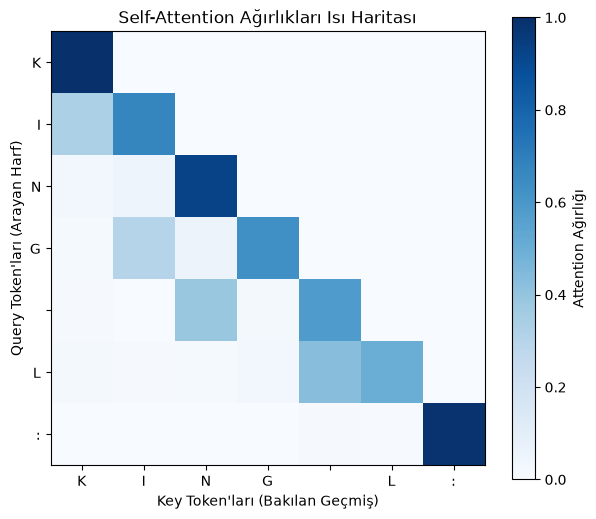

In [23]:
import matplotlib.pyplot as plt

# 8 karakterlik örnek bir metin parçası seçelim
sample_text = "KING L:"
sample_tokens = torch.tensor([encode(sample_text)], dtype=torch.long) # (1, T)

model_sa.eval()
with torch.no_grad():
    # Head modülünden wei matrisini çekelim
    B, T = sample_tokens.shape
    tok_emb = model_sa.token_embedding_table(sample_tokens)
    pos_emb = model_sa.position_embedding_table(torch.arange(T))
    x = tok_emb + pos_emb
    
    k = model_sa.sa_head.key(x)
    q = model_sa.sa_head.query(x)
    wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)
    wei = wei.masked_fill(model_sa.sa_head.tril[:T, :T] == 0, float('-inf'))
    wei = F.softmax(wei, dim=-1)[0] # (T, T)

# Isı haritasını çizelim
plt.figure(figsize=(7, 6))
plt.imshow(wei.numpy(), cmap='Blues', interpolation='nearest')
plt.colorbar(label='Attention Ağırlığı')

tokens_labels = list(sample_text)
plt.xticks(range(len(tokens_labels)), tokens_labels)
plt.yticks(range(len(tokens_labels)), tokens_labels)

plt.xlabel("Key Token'ları (Bakılan Geçmiş)")
plt.ylabel("Query Token'ları (Arayan Harf)")
plt.title("Self-Attention Ağırlıkları Isı Haritası")
plt.grid(False)
plt.show()

### Isı Haritası Yorumu
- Matrisin sağ üst köşesi tamamen beyazdır (0.0 değerindedir), bu da alt üçgen maskelemenin geleceğe bakışı başarıyla engellediğini gösterir.
- Köşegen boyunca ve belirli sütunlarda (örneğin boşluk veya harf başlangıçları) koyu mavi yoğunlaşmalar görülür. Bu durum, modelin hece ve kelime sınırlarına dinamik olarak dikkat topladığını kanıtlar.